# SWIGGY SALES ANLAYSIS

#### IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_excel('swiggy_data.xlsx')

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


#### Meta Data

In [5]:
df.shape[0]

197430

In [6]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

#### Data types

In [7]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [8]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [9]:
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

#### KPI's

In [10]:
#Total Sales
total_sales = df['Price (INR)'].sum()
print('Total Sales (INR):' , round(total_sales,2))

Total Sales (INR): 53012505.77


In [11]:
#Avg Rating
avg_rating = df['Rating Count'].mean()
print('Average Rating:' , round(avg_rating,1))

Average Rating: 28.3


In [12]:
#Avg Order Value
avg_order_value = df['Price (INR)'].mean()
print('Average Order Value:' , round(avg_order_value,1))

Average Order Value: 268.5


In [13]:
#Rating count
rating_count = df['Rating Count'].sum()
print('Total Rating Count:' , round(rating_count,1))

Total Rating Count: 5591574


In [14]:
#Total Orders
total_orders = df['Order Date'].count()
print('Total Orders:' , round(total_orders,1))

Total Orders: 197430


#### Charts

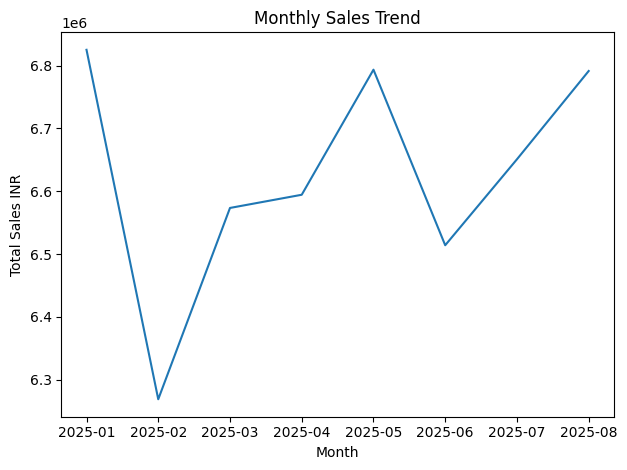

In [15]:
#Monthly Sales trend
df['Order Date'] = pd.to_datetime(df['Order Date']) #converting to date time data type
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str) #dt.to_period 'M' will give year and month
monthly_revenue = df.groupby('YearMonth')['Price (INR)'].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Price (INR)'])
plt.xticks
plt.xlabel('Month')
plt.ylabel('Total Sales INR')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()


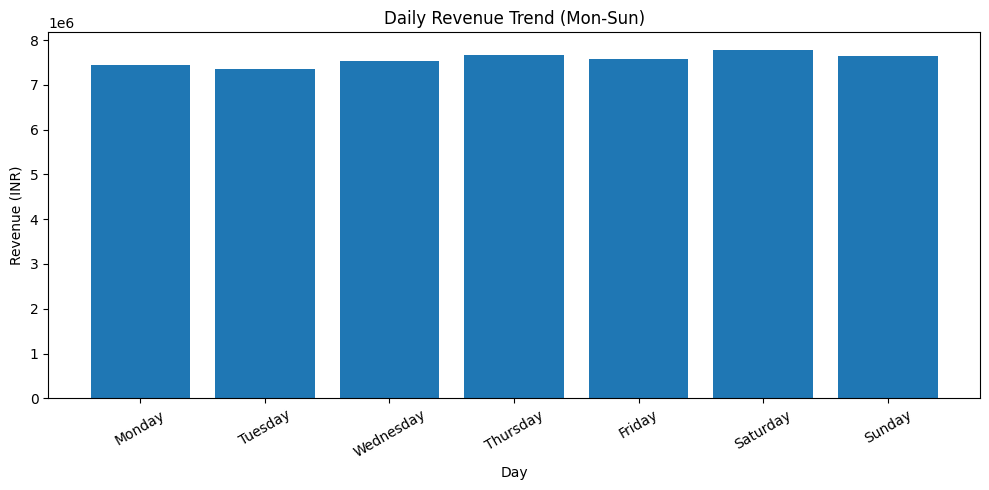

In [18]:
#Daily sales trend
df['DayName'] = pd.to_datetime(df['Order Date']).dt.day_name()

daily_revenue = (
    df.groupby('DayName')['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.xlabel('Day')
plt.ylabel('Revenue (INR)')
plt.title('Daily Revenue Trend (Mon-Sun)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
#total sales by food type (veg-non-veg)
non_veg_keywords = (
    "chicken", "egg", "fish", "mutton", "prawn", "biryani", "kabab", "kebab", "non-veg", "non veg"
)

df['Food Category'] = np.where(
    df['Dish Name'].str.lower().str.contains('|'.join(non_veg_keywords), na=False),
    'Non-Veg',
    'Veg'
)


In [22]:
food_revenue = (
    df.groupby('Food Category')['Price (INR)'].sum().reset_index()
)


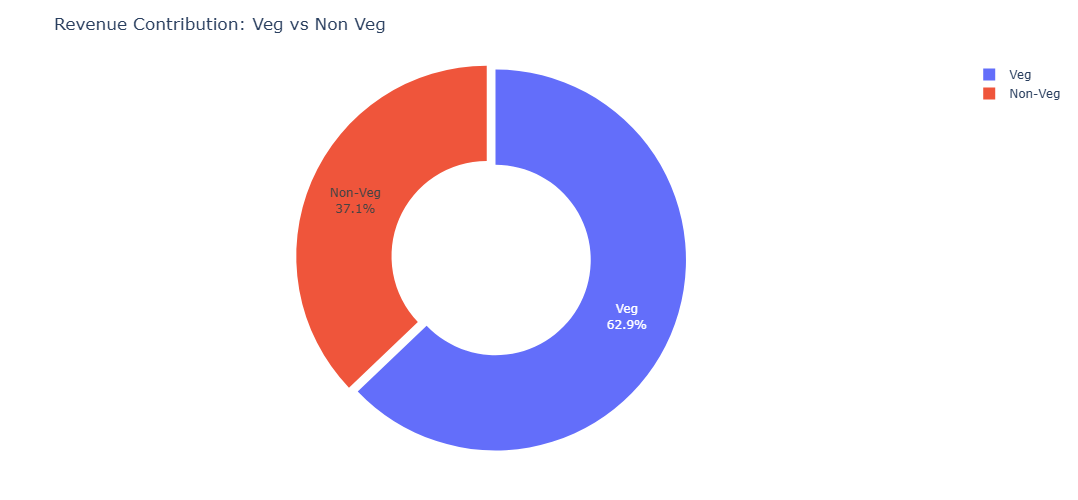

In [26]:
fig = px.pie(
    food_revenue,
    values = 'Price (INR)',
    names= 'Food Category',
    hole= 0.5,
    title = 'Revenue Contribution: Veg vs Non Veg',
)
fig.update_traces(
    textinfo='percent+label',
    pull=[0.05,0]
)
fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)
fig.show()

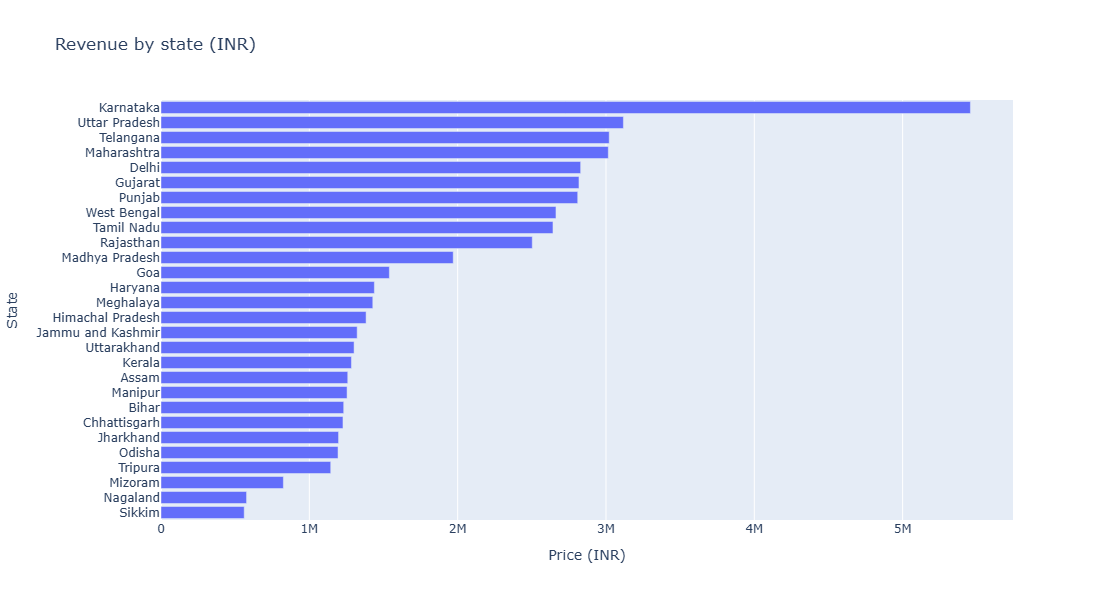

In [33]:
#Total sales by state
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum().sort_values(["Price (INR)"], ascending=False),
x='Price (INR)',
y= 'State',
orientation='h',
title='Revenue by state (INR)'
)
fig.update_layout(height=600, yaxis=dict(autorange='reversed'))
fig.show()

In [41]:
#quarterly performance summary
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)
quarterly_summary = (
    df.groupby("Quarter", as_index=False)
        .agg(
        Total_sales=('Price (INR)', 'sum'),
        Avg_rating=('Rating', 'mean'),
        Total_orders= ('Order Date', 'count')
    )
        .sort_values("Quarter")
)
quarterly_summary['Total_sales'] = quarterly_summary['Total_sales'].round(0)
quarterly_summary['Avg_rating'] = quarterly_summary['Avg_rating'].round(2)
quarterly_summary

,Quarter,Total_sales,Avg_rating,Total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


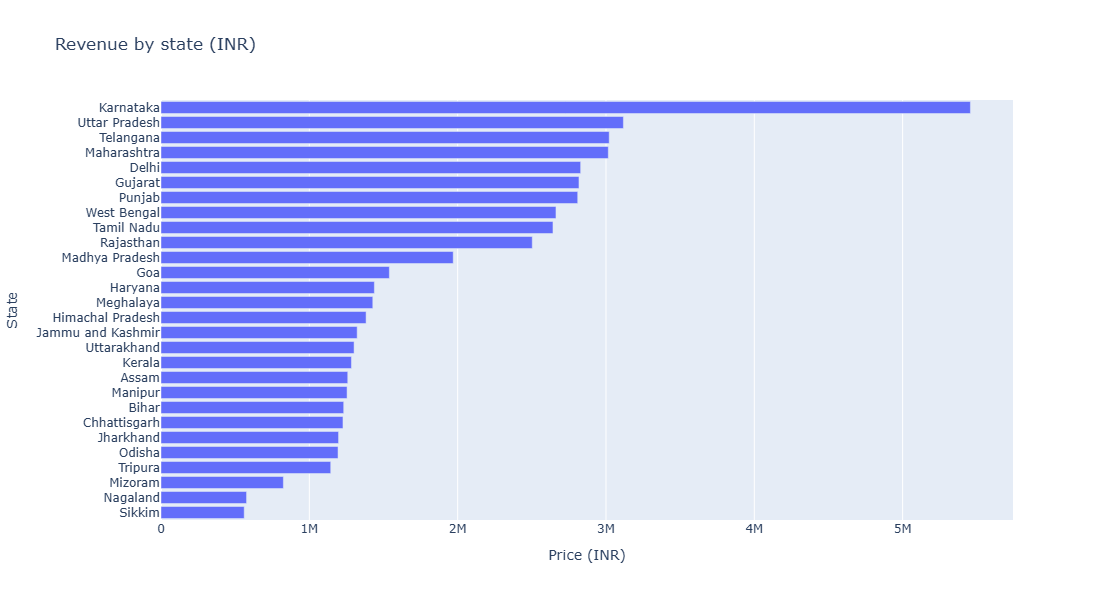

In [46]:
#top 5 cities by sales
top_5_cities = (
    df.groupby('City')['Price (INR)']
        .sum()
        .nlargest(5)
        .sort_values()
        .reset_index()
)
figure = px.bar(
top_5_cities,
x='Price (INR)',
y='City',
orientation='h',
title='Top 5 cities by sales(INR)',
color_discrete_sequence=['red']
)
fig.show()